In [161]:
#BUSINESS SCENARIO: THE NOVARETAIL E-COMMERCE CASE STUDY

In today’s competitive e-commerce landscape, companies invest heavily in marketing campaigns across multiple channels such as email, social media, and paid advertising. However, a key challenge remains: not all users respond equally to these campaigns, and a significant portion of marketing budget is often spent on low-probability customers.

NovaRetail, a mid-sized e-commerce company, is facing this exact problem. Despite running frequent promotional campaigns, the company lacks a data-driven approach to identify which users are most likely to convert after interacting with marketing content.

As a result, campaigns are currently applied uniformly across the entire user base, leading to inefficient budget allocation and suboptimal return on investment (ROI).

To address this challenge, NovaRetail aims to leverage machine learning to predict customer conversion probability based on user behavior, engagement with marketing campaigns, and historical purchase data.

The goal of this project is to build a predictive model that can estimate the likelihood of conversion for each user. By doing so, the company can prioritize high-probability customers, personalize marketing strategies, and significantly improve campaign effectiveness.

In [162]:
#MACHINE LEARNING PROJECT OBJECTIVE

The primary objective of this project is to develop a machine learning model that predicts whether a user will convert (make a purchase) after being exposed to a marketing campaign. The model will be trained on a dataset containing demographic information, behavioral metrics, and campaign interaction data.

In addition to building the model, the project aims to:
1. evaluate model performance using appropriate classification metrics
2. optimize the model through hyperparameter tuning
3. optimize the model through hyperparameter tuning
4. translate model outputs into actionable business insights

In [163]:
#WHY DOES THIS PROBLEM MATTER

Solving this problem enables a shift from broad, non-targeted campaigns to a more strategic and data-driven approach. Instead of treating all users equally, the company can focus its resources on the customers most likely to convert, improving efficiency and maximizing marketing ROI.

In [164]:
import numpy as np
import pandas as pd

# Per rendere i risultati riproducibili
np.random.seed(42)

# Numero di righe del dataset
n = 3000

# -----------------------------
# 1. GENERAZIONE DELLE FEATURE
# -----------------------------

age = np.random.randint(18, 70, n)

annual_income = np.random.normal(loc=55000, scale=18000, size=n)
annual_income = np.clip(annual_income, 18000, 150000).round(0)

gender = np.random.choice(['Male', 'Female'], size=n, p=[0.48, 0.52])

city_tier = np.random.choice(['Tier 1', 'Tier 2', 'Tier 3'], size=n, p=[0.5, 0.3, 0.2])

website_visits_last_30d = np.random.poisson(lam=7, size=n)
website_visits_last_30d = np.clip(website_visits_last_30d, 0, 30)

pages_per_visit = np.random.normal(loc=4.0, scale=1.5, size=n)
pages_per_visit = np.clip(pages_per_visit, 1.0, 10.0).round(2)

avg_session_duration_min = np.random.normal(loc=5.5, scale=2.0, size=n)
avg_session_duration_min = np.clip(avg_session_duration_min, 0.5, 20.0).round(2)

cart_additions_last_30d = np.random.poisson(lam=1.5, size=n)
cart_additions_last_30d = np.clip(cart_additions_last_30d, 0, 12)

previous_purchases = np.random.poisson(lam=2.2, size=n)
previous_purchases = np.clip(previous_purchases, 0, 20)

campaign_channel = np.random.choice(
    ['Email', 'SMS', 'Social', 'Search Ads'],
    size=n,
    p=[0.35, 0.15, 0.25, 0.25]
)

campaign_type = np.random.choice(
    ['Discount', 'New Arrival', 'Retargeting', 'Seasonal'],
    size=n,
    p=[0.35, 0.20, 0.25, 0.20]
)

discount_percentage = np.random.choice(
    [0, 5, 10, 15, 20, 25, 30],
    size=n,
    p=[0.10, 0.12, 0.20, 0.22, 0.18, 0.12, 0.06]
)

product_price = np.random.normal(loc=80, scale=30, size=n)
product_price = np.clip(product_price, 10, 300).round(2)

loyalty_member = np.random.choice([0, 1], size=n, p=[0.65, 0.35])

# Se previous_purchases = 0, days_since_last_purchase sarà molto alto
days_since_last_purchase = []
for pp in previous_purchases:
    if pp == 0:
        days_since_last_purchase.append(np.random.randint(180, 1000))
    else:
        days_since_last_purchase.append(np.random.randint(1, 180))
days_since_last_purchase = np.array(days_since_last_purchase)

# -----------------------------
# 2. INTERAZIONI MARKETING
# -----------------------------
# Rendiamo opens/clicks più realistici e dipendenti dal canale e dal comportamento

email_opened = []
email_clicked = []
sms_clicked = []
ad_clicked = []

for i in range(n):
    # Email opened
    if campaign_channel[i] == 'Email':
        p_open = 0.55
    else:
        p_open = 0.15

    if loyalty_member[i] == 1:
        p_open += 0.08
    if previous_purchases[i] >= 3:
        p_open += 0.05

    opened = np.random.binomial(1, min(max(p_open, 0.01), 0.95))
    email_opened.append(opened)

    # Email clicked
    if opened == 1:
        p_email_click = 0.30
        if campaign_type[i] == 'Discount':
            p_email_click += 0.10
        if discount_percentage[i] >= 20:
            p_email_click += 0.07
    else:
        p_email_click = 0.03

    email_click = np.random.binomial(1, min(max(p_email_click, 0.01), 0.90))
    email_clicked.append(email_click)

    # SMS clicked
    if campaign_channel[i] == 'SMS':
        p_sms = 0.22
        if loyalty_member[i] == 1:
            p_sms += 0.05
    else:
        p_sms = 0.04

    sms_click = np.random.binomial(1, min(max(p_sms, 0.01), 0.80))
    sms_clicked.append(sms_click)

    # Ad clicked
    if campaign_channel[i] in ['Social', 'Search Ads']:
        p_ad = 0.25
        if website_visits_last_30d[i] >= 8:
            p_ad += 0.05
    else:
        p_ad = 0.06

    ad_click = np.random.binomial(1, min(max(p_ad, 0.01), 0.85))
    ad_clicked.append(ad_click)

email_opened = np.array(email_opened)
email_clicked = np.array(email_clicked)
sms_clicked = np.array(sms_clicked)
ad_clicked = np.array(ad_clicked)

# -----------------------------
# 3. CREAZIONE DEL TARGET
# -----------------------------
# Usiamo una funzione logistica per rendere la conversione realistica.
# Alcune variabili aumentano la probabilità di conversione, altre la riducono.

score = (
    -4.2
    + 0.015 * website_visits_last_30d
    + 0.22 * pages_per_visit
    + 0.10 * avg_session_duration_min
    + 0.45 * cart_additions_last_30d
    + 0.18 * previous_purchases
    + 0.60 * loyalty_member
    + 0.75 * email_clicked
    + 0.55 * sms_clicked
    + 0.70 * ad_clicked
    + 0.035 * discount_percentage
    - 0.004 * product_price
    - 0.0035 * days_since_last_purchase
)

# Effetti del campaign_type
score += np.where(campaign_type == 'Retargeting', 0.45, 0)
score += np.where(campaign_type == 'Discount', 0.30, 0)
score += np.where(campaign_type == 'New Arrival', 0.10, 0)
score += np.where(campaign_type == 'Seasonal', 0.05, 0)

# Effetti del city_tier
score += np.where(city_tier == 'Tier 1', 0.10, 0)
score += np.where(city_tier == 'Tier 2', 0.05, 0)

# Effetto reddito moderato
score += 0.000004 * annual_income

# Un po' di rumore casuale per evitare dati troppo perfetti
score += np.random.normal(0, 0.5, n)

# Funzione logistica
conversion_probability = 1 / (1 + np.exp(-score))

# Target finale
converted = np.random.binomial(1, conversion_probability)

# -----------------------------
# 4. CREAZIONE DATAFRAME
# -----------------------------
df = pd.DataFrame({
    'age': age,
    'annual_income': annual_income.astype(int),
    'gender': gender,
    'city_tier': city_tier,
    'website_visits_last_30d': website_visits_last_30d,
    'pages_per_visit': pages_per_visit,
    'avg_session_duration_min': avg_session_duration_min,
    'cart_additions_last_30d': cart_additions_last_30d,
    'previous_purchases': previous_purchases,
    'email_opened': email_opened,
    'email_clicked': email_clicked,
    'sms_clicked': sms_clicked,
    'ad_clicked': ad_clicked,
    'campaign_channel': campaign_channel,
    'campaign_type': campaign_type,
    'discount_percentage': discount_percentage,
    'product_price': product_price,
    'days_since_last_purchase': days_since_last_purchase,
    'loyalty_member': loyalty_member,
    'converted': converted
})

# -----------------------------
# 5. SALVATAGGIO E CONTROLLO
# -----------------------------
print(df.head())
print("\nShape of dataset:", df.shape)
print("\nConversion rate:")
print(df['converted'].value_counts(normalize=True).round(3))

# Salva il file CSV
df.to_csv('marketing_conversion_dataset.csv', index=False)

print("\nFile saved as 'marketing_conversion_dataset.csv'")

   age  annual_income  gender city_tier  website_visits_last_30d  \
0   56          70076    Male    Tier 1                        3   
1   69          40354    Male    Tier 1                        9   
2   46          76847  Female    Tier 1                       10   
3   32          52479  Female    Tier 2                        4   
4   60          70995  Female    Tier 1                        5   

   pages_per_visit  avg_session_duration_min  cart_additions_last_30d  \
0             4.68                      8.81                        1   
1             3.28                      5.42                        2   
2             1.00                      4.50                        4   
3             4.88                      3.18                        0   
4             6.19                      6.62                        2   

   previous_purchases  email_opened  email_clicked  sms_clicked  ad_clicked  \
0                   4             1              0            0          

In [165]:
#STEP 1: LOAD THE DATASET AND RUN PRELIMINARY EXPLORATORY DATA ANALYSIS (EDA)

In [166]:
#Import the Necessary Libraries

In [167]:
import pandas as pd
import numpy as np

In [168]:
#Load the Dataset

In [169]:
df=pd.read_csv('marketing_conversion_dataset.csv')

In [170]:
#Display the First 5 Rows

In [171]:
print("First 5 rows:")
print(df.head())

First 5 rows:
   age  annual_income  gender city_tier  website_visits_last_30d  \
0   56          70076    Male    Tier 1                        3   
1   69          40354    Male    Tier 1                        9   
2   46          76847  Female    Tier 1                       10   
3   32          52479  Female    Tier 2                        4   
4   60          70995  Female    Tier 1                        5   

   pages_per_visit  avg_session_duration_min  cart_additions_last_30d  \
0             4.68                      8.81                        1   
1             3.28                      5.42                        2   
2             1.00                      4.50                        4   
3             4.88                      3.18                        0   
4             6.19                      6.62                        2   

   previous_purchases  email_opened  email_clicked  sms_clicked  ad_clicked  \
0                   4             1              0         

In [172]:
#Check the Dataset Shape

In [173]:
df.shape

(3000, 20)

In [174]:
#Show the Column Names

In [175]:
df.columns

Index(['age', 'annual_income', 'gender', 'city_tier',
       'website_visits_last_30d', 'pages_per_visit',
       'avg_session_duration_min', 'cart_additions_last_30d',
       'previous_purchases', 'email_opened', 'email_clicked', 'sms_clicked',
       'ad_clicked', 'campaign_channel', 'campaign_type',
       'discount_percentage', 'product_price', 'days_since_last_purchase',
       'loyalty_member', 'converted'],
      dtype='object')

In [176]:
#Check the Data Types and Structure

In [177]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 20 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   age                       3000 non-null   int64  
 1   annual_income             3000 non-null   int64  
 2   gender                    3000 non-null   object 
 3   city_tier                 3000 non-null   object 
 4   website_visits_last_30d   3000 non-null   int64  
 5   pages_per_visit           3000 non-null   float64
 6   avg_session_duration_min  3000 non-null   float64
 7   cart_additions_last_30d   3000 non-null   int64  
 8   previous_purchases        3000 non-null   int64  
 9   email_opened              3000 non-null   int64  
 10  email_clicked             3000 non-null   int64  
 11  sms_clicked               3000 non-null   int64  
 12  ad_clicked                3000 non-null   int64  
 13  campaign_channel          3000 non-null   object 
 14  campaign

In [178]:
#Check for Missing Values

In [179]:
df.isnull().sum()

,0
age,0
annual_income,0
gender,0
city_tier,0
website_visits_last_30d,0
pages_per_visit,0
avg_session_duration_min,0
cart_additions_last_30d,0
previous_purchases,0
email_opened,0


In [180]:
print("\nTotal missing values in dataset:")
print(df.isnull().sum().sum())


Total missing values in dataset:
0


In [181]:
#Descriptive Statistics for Numerical Columns

In [182]:
df.describe()

,age,annual_income,website_visits_last_30d,pages_per_visit,avg_session_duration_min,cart_additions_last_30d,previous_purchases,email_opened,email_clicked,sms_clicked,ad_clicked,discount_percentage,product_price,days_since_last_purchase,loyalty_member,converted
count,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000
mean,43.563000,54898.346333,7.011333,4.012297,5.523567,1.462333,2.231667,0.338333,0.135667,0.073333,0.156667,14.370000,79.319493,140.752667,0.357667,0.334000
std,14.941791,17496.187481,2.696101,1.460924,1.983869,1.216994,1.477630,0.473221,0.342491,0.260726,0.363547,8.302173,30.187970,176.792634,0.479393,0.471718
min,18.000000,18000.000000,0.000000,1.000000,0.500000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,10.000000,1.000000,0.000000,0.000000
25%,31.000000,42646.500000,5.000000,2.990000,4.160000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,10.000000,58.790000,50.000000,0.000000,0.000000
50%,44.000000,54658.000000,7.000000,4.030000,5.460000,1.000000,2.000000,0.000000,0.000000,0.000000,0.000000,15.000000,79.265000,98.000000,0.000000,0.000000
75%,56.000000,67202.000000,9.000000,5.020000,6.860000,2.000000,3.000000,1.000000,0.000000,0.000000,0.000000,20.000000,99.272500,151.000000,1.000000,1.000000
max,69.000000,110115.000000,19.000000,8.770000,13.530000,9.000000,10.000000,1.000000,1.000000,1.000000,1.000000,30.000000,183.320000,998.000000,1.000000,1.000000


In [183]:
#Descriptive Statistics for All Columns

In [184]:
df.describe(include='all')

,age,annual_income,gender,city_tier,website_visits_last_30d,pages_per_visit,avg_session_duration_min,cart_additions_last_30d,previous_purchases,email_opened,email_clicked,sms_clicked,ad_clicked,campaign_channel,campaign_type,discount_percentage,product_price,days_since_last_purchase,loyalty_member,converted
count,3000.000000,3000.000000,3000,3000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000,3000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000
unique,NaN,NaN,2,3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4,4,NaN,NaN,NaN,NaN,NaN
top,NaN,NaN,Female,Tier 1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Email,Discount,NaN,NaN,NaN,NaN,NaN
freq,NaN,NaN,1523,1502,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1049,1047,NaN,NaN,NaN,NaN,NaN
mean,43.563000,54898.346333,NaN,NaN,7.011333,4.012297,5.523567,1.462333,2.231667,0.338333,0.135667,0.073333,0.156667,NaN,NaN,14.370000,79.319493,140.752667,0.357667,0.334000
std,14.941791,17496.187481,NaN,NaN,2.696101,1.460924,1.983869,1.216994,1.477630,0.473221,0.342491,0.260726,0.363547,NaN,NaN,8.302173,30.187970,176.792634,0.479393,0.471718
min,18.000000,18000.000000,NaN,NaN,0.000000,1.000000,0.500000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,NaN,NaN,0.000000,10.000000,1.000000,0.000000,0.000000
25%,31.000000,42646.500000,NaN,NaN,5.000000,2.990000,4.160000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,NaN,NaN,10.000000,58.790000,50.000000,0.000000,0.000000
50%,44.000000,54658.000000,NaN,NaN,7.000000,4.030000,5.460000,1.000000,2.000000,0.000000,0.000000,0.000000,0.000000,NaN,NaN,15.000000,79.265000,98.000000,0.000000,0.000000
75%,56.000000,67202.000000,NaN,NaN,9.000000,5.020000,6.860000,2.000000,3.000000,1.000000,0.000000,0.000000,0.000000,NaN,NaN,20.000000,99.272500,151.000000,1.000000,1.000000


In [185]:
#Check for Duplicate Rows

In [186]:
df.duplicated().sum()

np.int64(0)

In [187]:
#Distribution of the Target Variable

In [188]:
df["converted"].value_counts()

,count
converted,
0,1998
1,1002


In [189]:
print("\nTarget variable distribution (proportions):")
print(df["converted"].value_counts(normalize=True).round(3))


Target variable distribution (proportions):
converted
0    0.666
1    0.334
Name: proportion, dtype: float64


In [190]:
#Check the Categorical Columns

In [191]:
categorical_columns = df.select_dtypes(include=["object"]).columns
categorical_columns

Index(['gender', 'city_tier', 'campaign_channel', 'campaign_type'], dtype='object')

In [192]:
for col in categorical_columns:
    print(f"\nColumn: {col}")
    print(df[col].value_counts())


Column: gender
gender
Female    1523
Male      1477
Name: count, dtype: int64

Column: city_tier
city_tier
Tier 1    1502
Tier 2     908
Tier 3     590
Name: count, dtype: int64

Column: campaign_channel
campaign_channel
Email         1049
Search Ads     757
Social         745
SMS            449
Name: count, dtype: int64

Column: campaign_type
campaign_type
Discount       1047
Retargeting     763
Seasonal        603
New Arrival     587
Name: count, dtype: int64


In [193]:
#Summary of STEP 1

In Step 1, the dataset was loaded and inspected to understand its structure, variable types, missing values, duplicates, and target distribution. This preliminary exploration helps ensure data quality before preprocessing and model training.

In [194]:
#STEP 2: DEFINE FEATURES, TARGET VARIABLE AND SPLIT TRAIN/TEST SETS

In [195]:
#Import the Necessary Library

In [196]:
from sklearn.model_selection import train_test_split

In [197]:
#Define the Target Variable

In [198]:
y = df["converted"]

In [199]:
#Drop the Target Variable from the Features Matrix

In [200]:
X = df.drop(columns=["converted"])

In [201]:
#Check the Shapes of X and y

In [202]:
print("Shape of X (features):", X.shape)
print("Shape of y (target):", y.shape)

Shape of X (features): (3000, 19)
Shape of y (target): (3000,)


In [203]:
#Perform the Train/Test Sets Split

In [204]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [205]:
#Check the Shapes After the Split

In [206]:
print("\nAfter train/test split:")
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)


After train/test split:
X_train shape: (2400, 19)
X_test shape: (600, 19)
y_train shape: (2400,)
y_test shape: (600,)


In [207]:
#Check the Distribution of the Target Variable in Train and Test Sets

In [208]:
print("\nTarget distribution in y_train:")
print(y_train.value_counts(normalize=True).round(3))

print("\nTarget distribution in y_test:")
print(y_test.value_counts(normalize=True).round(3))


Target distribution in y_train:
converted
0    0.666
1    0.334
Name: proportion, dtype: float64

Target distribution in y_test:
converted
0    0.667
1    0.333
Name: proportion, dtype: float64


In [209]:
#Summary of STEP 2

In Step 2, the dataset was split into features (X) and target (y), where the goal is to predict customer conversion. The data was then divided into training and test sets using an 80/20 split. Stratified sampling was applied to preserve the original class distribution, ensuring a reliable evaluation of the model on unseen data.

In [210]:
#STEP 3: PREPROCESSING WITH COLUMNTRANSFORMER()

In [211]:
#Import the Necessary Tools

In [212]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline

In [213]:
#Define Numerical and Categorical Columns

In [214]:
numerical_features = [
    'age',
    'annual_income',
    'website_visits_last_30d',
    'pages_per_visit',
    'avg_session_duration_min',
    'cart_additions_last_30d',
    'previous_purchases',
    'email_opened',
    'email_clicked',
    'sms_clicked',
    'ad_clicked',
    'discount_percentage',
    'product_price',
    'days_since_last_purchase',
    'loyalty_member'
]

In [215]:
categorical_features = [
    'gender',
    'city_tier',
    'campaign_channel',
    'campaign_type'
]


In [216]:
#Numerical Pipeline

In [217]:
numerical_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

In [218]:
#Categorical Pipeline

In [219]:
categorical_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore'))
])

In [220]:
#Combine with the ColumnTransformer()

In [221]:
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numerical_pipeline, numerical_features),
        ('cat', categorical_pipeline, categorical_features)
    ]
)

In [222]:
#Display the Result

In [223]:
print("Advanced preprocessor with pipelines:\n")
print(preprocessor)

Advanced preprocessor with pipelines:

ColumnTransformer(transformers=[('num',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='median')),
                                                 ('scaler', StandardScaler())]),
                                 ['age', 'annual_income',
                                  'website_visits_last_30d', 'pages_per_visit',
                                  'avg_session_duration_min',
                                  'cart_additions_last_30d',
                                  'previous_purchases', 'email_opened',
                                  'email_clicked', 'sms_clicked', 'ad_clicked',
                                  'discount_percentage', 'product_price',
                                  'days_since_last_purchase',
                                  'loyalty_member']),
                                ('cat',
                                 Pipeline(steps=[('

In [224]:
#Summary of STEP 3

In Step 3, separate preprocessing pipelines were created for numerical and categorical features. Missing values in numerical features were imputed using the median and then scaled, while categorical features were imputed using the most frequent value and encoded using OneHotEncoder. These transformations were combined using a ColumnTransformer to ensure a clean and robust preprocessing workflow.

In [225]:
#STEP 4: BUILD THE FULL PIPELINE

In [226]:
#Import the Necessary Tools

In [227]:
from sklearn.pipeline import Pipeline
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.linear_model import LogisticRegression

In [228]:
#Create the Full Pipeline

In [229]:
model_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('feature_selection', SelectKBest(score_func=f_classif, k=10)),
    ('model', LogisticRegression(max_iter=1000, random_state=42))
])

In [230]:
#Display the Pipeline

In [231]:
print("Full pipeline created successfully:\n")
print(model_pipeline)

Full pipeline created successfully:

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['age', 'annual_income',
                                                   'website_visits_last_30d',
                                                   'pages_per_visit',
                                                   'avg_session_duration_min',
                                                   'cart_additions_last_30d',
                                                   'previous_purchases',
                                                   'email_opened',
        

In [232]:
#Summary of STEP 4

In Step 4, an end-to-end machine learning pipeline was created by combining preprocessing, feature selection, and Logistic Regression into a single workflow. This approach improves code organization, prevents data leakage, and ensures that all transformations are applied consistently during training and evaluation.

In [233]:
#STEP 5: FIT THE PIPELINE AND GENERATE FIRST PREDICTIONS

In [234]:
#Fit the Pipeline on the Training Data

In [235]:
model_pipeline.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['age', 'annual_income',
                                                   'website_visits_last_30d',
                                                   'pages_per_visit',
                                                   'avg_session_duration_min',
                                                   'cart_additions_last_30d',
                                                   'previous_purchases',
                                                   'email_opened',
                                                   'email_clicked',
                                                   'sms_clicked', 'a...
                                                   'discount_percentage',
                                                   'product_price',
                                                   'days_since_last_purchase',
                                                   'loyalty_member']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['gender', 'city_tier',
                                                   'campaign_channel',
                                                   'campaign_type'])])),
                ('feature_selection', SelectKBest()),
                ('model', LogisticRegression(max_iter=1000, random_state=42))])

In [236]:
#Predict Class Labels on the Test Set

In [237]:
y_pred = model_pipeline.predict(X_test)

In [238]:
#Predict Probabilities on the Test Set

In [239]:
y_pred_proba = model_pipeline.predict_proba(X_test)[:, 1]

In [240]:
#Display First Predictions

In [241]:
print("First 10 predicted classes:")
print(y_pred[:10])

First 10 predicted classes:
[0 1 0 0 0 0 0 0 0 1]


In [242]:
print("\nFirst 10 predicted probabilities:")
print(y_pred_proba[:10])


First 10 predicted probabilities:
[0.2128151  0.57912989 0.49201232 0.31012738 0.43086277 0.2034469
 0.43405014 0.30300927 0.30957679 0.73398154]


In [243]:
#Compare Actual vs Predicted Values

In [244]:
comparison_df = pd.DataFrame({
    'Actual': y_test.values[:10],
    'Predicted': y_pred[:10],
    'Predicted_Probability': y_pred_proba[:10]
})

In [245]:
print("\nComparison of actual vs predicted (first 10 rows):")
print(comparison_df)


Comparison of actual vs predicted (first 10 rows):
   Actual  Predicted  Predicted_Probability
0       0          0               0.212815
1       1          1               0.579130
2       0          0               0.492012
3       1          0               0.310127
4       1          0               0.430863
5       0          0               0.203447
6       1          0               0.434050
7       0          0               0.303009
8       0          0               0.309577
9       1          1               0.733982


In [246]:
#Summary of STEP 5

In Step 5, the full pipeline was fitted on the training set. Predictions were then generated on the unseen test set, both as class labels and as conversion probabilities. This allows the model not only to classify whether a customer is likely to convert, but also to estimate the probability of conversion, which is especially useful in marketing decision-making.

In [247]:
#STEP 6: BASELINE MODEL EVALUATION

In [248]:
#Import Evaluation Metrics

In [249]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_auc_score

In [250]:
#Accuracy

In [251]:
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", round(accuracy, 4))

Accuracy: 0.725


In [252]:
#Confusion Matrix

In [253]:
cm = confusion_matrix(y_test, y_pred)
print("\nConfusion Matrix:")
print(cm)


Confusion Matrix:
[[358  42]
 [123  77]]


In [254]:
#Classification Report

In [255]:
print("\nClassification Report:")
print(classification_report(y_test, y_pred))


Classification Report:
              precision    recall  f1-score   support

           0       0.74      0.90      0.81       400
           1       0.65      0.39      0.48       200

    accuracy                           0.72       600
   macro avg       0.70      0.64      0.65       600
weighted avg       0.71      0.72      0.70       600



In [256]:
#ROC-AUC Score

In [257]:
roc_auc = roc_auc_score(y_test, y_pred_proba)
print("ROC-AUC Score:", round(roc_auc, 4))

ROC-AUC Score: 0.7491


In [258]:
#Summary of STEP 6

In Step 6, the model was evaluated on the unseen test set using multiple classification metrics. Accuracy was used as a general measure of correctness, while the confusion matrix provided insight into true and false predictions. The classification report offered a detailed view of precision, recall, and F1-score for each class. Finally, ROC-AUC was used to assess how well the model distinguishes between converting and non-converting customers.

In [259]:
#STEP 7: HYPERPARAMETER TUNING WITH GRIDSEARCHCV()

In [260]:
#Import GridSearchCV()

In [261]:
from sklearn.model_selection import GridSearchCV

In [262]:
#Define the Parameter Grid

In [263]:
param_grid = {
    'feature_selection__k': [8, 10, 12, 'all'],
    'model__C': [0.01, 0.1, 1, 10],
    'model__solver': ['liblinear', 'lbfgs']
}

In [264]:
#Create a GridSearchCV Object

In [265]:
from sklearn.model_selection import StratifiedKFold

cv_strategy = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

In [266]:
grid_search = GridSearchCV(
    estimator=model_pipeline,
    param_grid=param_grid,
    cv=cv_strategy,
    scoring='roc_auc',
    n_jobs=-1,
    verbose=1
)

In [267]:
#Fit the GridSearchCV on the Training Data

In [268]:
grid_search.fit(X_train, y_train)

Fitting 5 folds for each of 32 candidates, totalling 160 fits


GridSearchCV(cv=StratifiedKFold(n_splits=5, random_state=42, shuffle=True),
             estimator=Pipeline(steps=[('preprocessor',
                                        ColumnTransformer(transformers=[('num',
                                                                         Pipeline(steps=[('imputer',
                                                                                          SimpleImputer(strategy='median')),
                                                                                         ('scaler',
                                                                                          StandardScaler())]),
                                                                         ['age',
                                                                          'annual_income',
                                                                          'website_visits_last_30d',
                                                                          'pages_per_visit',
                                                                          'avg_session_duration_min',
                                                                          'cart_addit...
                                                                                          OneHotEncoder(handle_unknown='ignore'))]),
                                                                         ['gender',
                                                                          'city_tier',
                                                                          'campaign_channel',
                                                                          'campaign_type'])])),
                                       ('feature_selection', SelectKBest()),
                                       ('model',
                                        LogisticRegression(max_iter=1000,
                                                           random_state=42))]),
             n_jobs=-1,
             param_grid={'feature_selection__k': [8, 10, 12, 'all'],
                         'model__C': [0.01, 0.1, 1, 10],
                         'model__solver': ['liblinear', 'lbfgs']},
             scoring='roc_auc', verbose=1)

In [269]:
#Print the Best Parameters

In [270]:
print("Best Parameters:")
print(grid_search.best_params_)

Best Parameters:
{'feature_selection__k': 'all', 'model__C': 0.01, 'model__solver': 'lbfgs'}


In [271]:
#Print the Best Cross-Validation Score

In [272]:
print("\nBest Cross-Validation ROC-AUC:")
print(round(grid_search.best_score_, 4))


Best Cross-Validation ROC-AUC:
0.7302


In [273]:
#Store the Best Model with best_estimator_

In [274]:
best_model = grid_search.best_estimator_

In [275]:
#Display the Best Model

In [276]:
print("\nBest Estimator:")
print(best_model)


Best Estimator:
Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['age', 'annual_income',
                                                   'website_visits_last_30d',
                                                   'pages_per_visit',
                                                   'avg_session_duration_min',
                                                   'cart_additions_last_30d',
                                                   'previous_purchases',
                                                   'email_opened',
                            

In [277]:
#Summary of STEP 7

In Step 7, GridSearchCV was used to optimize the machine learning pipeline by tuning both feature selection and Logistic Regression hyperparameters. A 5-fold cross-validation strategy was applied, and ROC-AUC was chosen as the evaluation metric because of its relevance in binary classification and marketing conversion prediction. The best estimator was then selected for final evaluation.

In [278]:
#STEP 8: EVALUATE THE BEST TUNED MODEL ON THE TEST SET

In [279]:
#Generate Predictions Using the Tuned Model

In [280]:
y_pred_best = best_model.predict(X_test)

In [281]:
#Generate Predicted Probabilities for the Positive (1) Class

In [282]:
y_pred_best_proba = best_model.predict_proba(X_test)[:, 1]

In [283]:
#Making Sure We Have the Evaluation Metrics

In [284]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_auc_score

In [285]:
#Accuracy

In [286]:
best_accuracy = accuracy_score(y_test, y_pred_best)
print("Tuned Model Accuracy:", round(best_accuracy, 4))

Tuned Model Accuracy: 0.7117


In [287]:
#Confusion Matrix

In [288]:
best_cm = confusion_matrix(y_test, y_pred_best)
print("\nTuned Model Confusion Matrix:")
print(best_cm)


Tuned Model Confusion Matrix:
[[364  36]
 [137  63]]


In [289]:
#Classification Report

In [290]:
print("\nTuned Model Classification Report:")
print(classification_report(y_test, y_pred_best))


Tuned Model Classification Report:
              precision    recall  f1-score   support

           0       0.73      0.91      0.81       400
           1       0.64      0.32      0.42       200

    accuracy                           0.71       600
   macro avg       0.68      0.61      0.61       600
weighted avg       0.70      0.71      0.68       600



In [291]:
#ROC-AUC Score

In [292]:
best_roc_auc = roc_auc_score(y_test, y_pred_best_proba)
print("Tuned Model ROC-AUC Score:", round(best_roc_auc, 4))

Tuned Model ROC-AUC Score: 0.7595


In [293]:
#Confusion Matrix Visualization

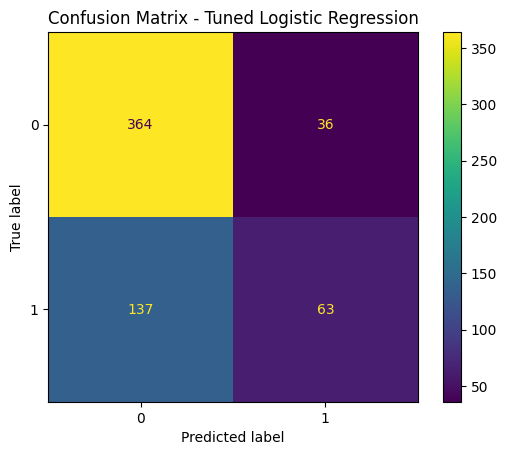

In [294]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_estimator(best_model, X_test, y_test)
plt.title("Confusion Matrix - Tuned Logistic Regression")
plt.show()

In [295]:
#ROC Curve Visualization

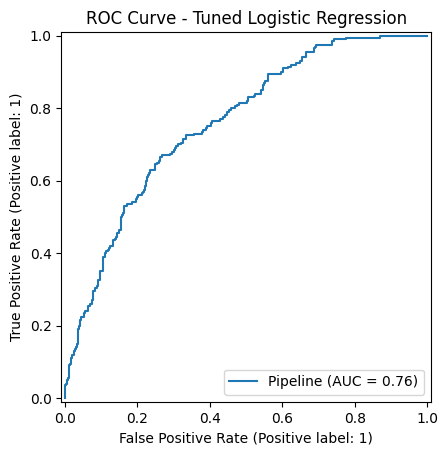

In [296]:
from sklearn.metrics import RocCurveDisplay

RocCurveDisplay.from_estimator(best_model, X_test, y_test)
plt.title("ROC Curve - Tuned Logistic Regression")
plt.show()

In [297]:
#PR (Precision-Recall) Curve Visualization

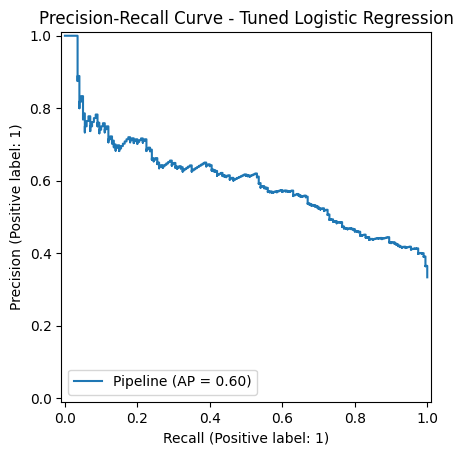

In [298]:
from sklearn.metrics import PrecisionRecallDisplay
import matplotlib.pyplot as plt

PrecisionRecallDisplay.from_estimator(best_model, X_test, y_test)
plt.title("Precision-Recall Curve - Tuned Logistic Regression")
plt.show()

In [299]:
#Logistic Regression Coefficients

                        Feature  Coefficient
5       cart_additions_last_30d     0.347446
11          discount_percentage     0.241735
3               pages_per_visit     0.217888
6            previous_purchases     0.205629
8                 email_clicked     0.164121
10                   ad_clicked     0.158183
14               loyalty_member     0.152031
9                   sms_clicked     0.127681
24       campaign_type_Discount     0.119299
4      avg_session_duration_min     0.107516
7                  email_opened     0.078358
2       website_visits_last_30d     0.046002
20       campaign_channel_Email     0.038317
16                  gender_Male     0.034434
19             city_tier_Tier 3     0.028937
22  campaign_channel_Search Ads     0.013049
18             city_tier_Tier 2     0.012703
26    campaign_type_Retargeting     0.005837
23      campaign_channel_Social     0.001373
1                 annual_income    -0.009323
0                           age    -0.010473
15        

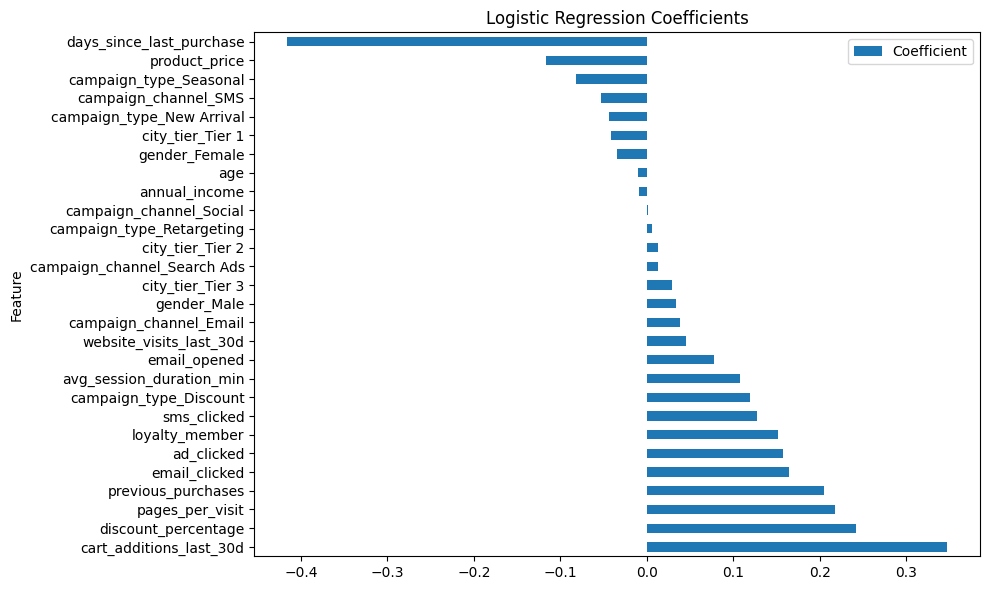

In [300]:
import pandas as pd
import matplotlib.pyplot as plt

encoded_cat_features = best_model.named_steps['preprocessor'] \
    .named_transformers_['cat'] \
    .named_steps['encoder'] \
    .get_feature_names_out(categorical_features)

all_feature_names = numerical_features + list(encoded_cat_features)

selected_mask = best_model.named_steps['feature_selection'].get_support()
selected_feature_names = pd.Index(all_feature_names)[selected_mask]

coefficients = best_model.named_steps['model'].coef_[0]

coef_df = pd.DataFrame({
    'Feature': selected_feature_names,
    'Coefficient': coefficients
}).sort_values(by='Coefficient', ascending=False)

print(coef_df)

coef_df.plot(
    kind='barh',
    x='Feature',
    y='Coefficient',
    figsize=(10, 6)
)
plt.title("Logistic Regression Coefficients")
plt.tight_layout()
plt.show()

In [301]:
#Summary of STEP 8

In Step 8, the best pipeline identified through GridSearchCV was evaluated on the unseen test set. Final predictions and conversion probabilities were generated, and the tuned model was assessed using accuracy, confusion matrix, classification report, and ROC-AUC. This final evaluation allowed us to compare the tuned model against the baseline and confirm whether hyperparameter optimization improved predictive performance.

In [302]:
#STEP 8 (EXTRA): Compare Logistic Regression Baseline Model vs Logistic Regression Tuned Model

In [303]:
print("===== BASELINE VS TUNED MODEL =====")
print(f"Baseline Accuracy: {accuracy:.4f}")
print(f"Tuned Accuracy:    {best_accuracy:.4f}")
print()
print(f"Baseline ROC-AUC:  {roc_auc:.4f}")
print(f"Tuned ROC-AUC:     {best_roc_auc:.4f}")

===== BASELINE VS TUNED MODEL =====
Baseline Accuracy: 0.7250
Tuned Accuracy:    0.7117

Baseline ROC-AUC:  0.7491
Tuned ROC-AUC:     0.7595


In [304]:
#STEP 9: High / Medium / Low Conversion Probability Segmentation Table

In [305]:
scored_customers = X_test.copy()
scored_customers['actual_conversion'] = y_test.values
scored_customers['predicted_probability'] = y_pred_best_proba

def probability_segment(p):
    if p >= 0.70:
        return 'High'
    elif p >= 0.40:
        return 'Medium'
    else:
        return 'Low'

scored_customers['segment'] = scored_customers['predicted_probability'].apply(probability_segment)

print(scored_customers[['predicted_probability', 'segment']].head())
print(scored_customers['segment'].value_counts())

      predicted_probability segment
2469               0.239485     Low
1787               0.585480  Medium
2660               0.516613  Medium
2735               0.367774     Low
189                0.461756  Medium
segment
Low       412
Medium    178
High       10
Name: count, dtype: int64


In [306]:
#STEP 10: BUSINESS INTERPRETATION & ACTIONABLE INSIGHTS

The final tuned model achieved a strong ROC-AUC score, indicating a good ability to distinguish between converting and non-converting users. This makes the model suitable for prioritizing high-probability customers in marketing campaigns.

By targeting only high-probability users, the company can significantly improve marketing efficiency and reduce wasted ad spend. Instead of treating all users equally, campaigns can be prioritized based on predicted conversion likelihood.

Instead of sending a discount to all users, the company could send targeted offers only to users with a predicted conversion probability above 0.7, increasing ROI and reducing unnecessary costs.

Logistic Regression was used as the primary model due to its interpretability, allowing the business to understand which factors most influence customer conversion.

Future improvements could include:

1. testing more advanced models such as Random Forest or Gradient Boosting
2. incorporating additional behavioral features
3. using real-time data for dynamic prediction
4. deploying the model into a production environment for live campaign optimization

In [307]:
#STEP 11: COMPARE LOGISTIC REGRESSION WITH RANDOM FOREST CLASSIFIER

In [308]:
#Build a Random Forest Classifier Pipeline

In [309]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline
from sklearn.feature_selection import SelectKBest, f_classif

rf_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('feature_selection', SelectKBest(score_func=f_classif, k=10)),
    ('model', RandomForestClassifier(random_state=42))
])

print("Random Forest pipeline created successfully:\n")
print(rf_pipeline)

Random Forest pipeline created successfully:

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['age', 'annual_income',
                                                   'website_visits_last_30d',
                                                   'pages_per_visit',
                                                   'avg_session_duration_min',
                                                   'cart_additions_last_30d',
                                                   'previous_purchases',
                                                   'email_opened',

In [310]:
#Tune the Random Forest Classifier Using GridSearchCV

In [311]:
from sklearn.model_selection import GridSearchCV

rf_param_grid = {
    'feature_selection__k': [8, 10, 12, 'all'],
    'model__n_estimators': [100, 200],
    'model__max_depth': [None, 5, 10],
    'model__min_samples_split': [2, 5]
}

rf_grid_search = GridSearchCV(
    estimator=rf_pipeline,
    param_grid=rf_param_grid,
    cv=5,
    scoring='roc_auc',
    n_jobs=-1,
    verbose=1
)

rf_grid_search.fit(X_train, y_train)

print("Best Random Forest Parameters:")
print(rf_grid_search.best_params_)

print("\nBest Random Forest Cross-Validation ROC-AUC:")
print(round(rf_grid_search.best_score_, 4))

best_rf_model = rf_grid_search.best_estimator_

print("\nBest Random Forest Estimator:")
print(best_rf_model)

Fitting 5 folds for each of 48 candidates, totalling 240 fits
Best Random Forest Parameters:
{'feature_selection__k': 'all', 'model__max_depth': 5, 'model__min_samples_split': 2, 'model__n_estimators': 200}

Best Random Forest Cross-Validation ROC-AUC:
0.7071

Best Random Forest Estimator:
Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['age', 'annual_income',
                                                   'website_visits_last_30d',
                                                   'pages_per_visit',
                                                   

In [312]:
#Evaluate Random Forest Classifier on Test Set

In [313]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_auc_score

In [314]:
y_pred_rf = best_rf_model.predict(X_test)
y_pred_rf_proba = best_rf_model.predict_proba(X_test)[:, 1]

In [315]:
rf_accuracy = accuracy_score(y_test, y_pred_rf)
rf_cm = confusion_matrix(y_test, y_pred_rf)
rf_roc_auc = roc_auc_score(y_test, y_pred_rf_proba)

print("===== RANDOM FOREST TEST PERFORMANCE =====")
print(f"Accuracy: {rf_accuracy:.4f}")
print(f"ROC-AUC Score: {rf_roc_auc:.4f}")

print("\nConfusion Matrix:")
print(rf_cm)

print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf))

===== RANDOM FOREST TEST PERFORMANCE =====
Accuracy: 0.6700
ROC-AUC Score: 0.7477

Confusion Matrix:
[[393   7]
 [191   9]]

Classification Report:
              precision    recall  f1-score   support

           0       0.67      0.98      0.80       400
           1       0.56      0.04      0.08       200

    accuracy                           0.67       600
   macro avg       0.62      0.51      0.44       600
weighted avg       0.64      0.67      0.56       600



In [316]:
#Feature Importance Measurement

                        Feature  Importance
13     days_since_last_purchase    0.185683
5       cart_additions_last_30d    0.130185
6            previous_purchases    0.116716
3               pages_per_visit    0.105582
11          discount_percentage    0.077387
12                product_price    0.060934
4      avg_session_duration_min    0.049040
8                 email_clicked    0.038540
1                 annual_income    0.036068
0                           age    0.033525
2       website_visits_last_30d    0.025424
10                   ad_clicked    0.023582
14               loyalty_member    0.022507
7                  email_opened    0.016182
9                   sms_clicked    0.015924
24       campaign_type_Discount    0.010688
27       campaign_type_Seasonal    0.005608
21         campaign_channel_SMS    0.005323
20       campaign_channel_Email    0.005233
16                  gender_Male    0.004467
17             city_tier_Tier 1    0.004452
19             city_tier_Tier 3 

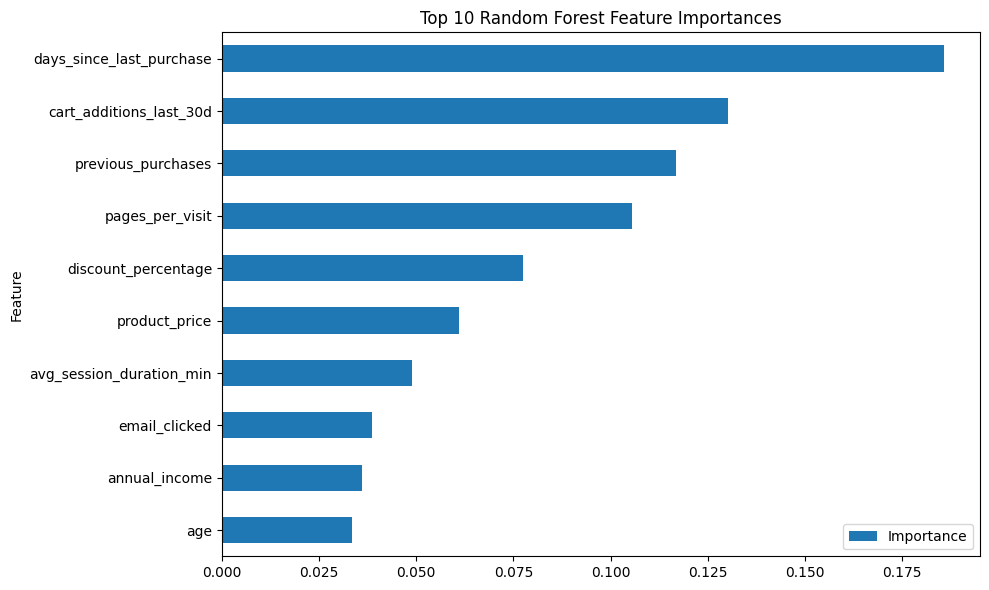

In [317]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. Get feature names after preprocessing
encoded_cat_features = best_rf_model.named_steps['preprocessor'] \
    .named_transformers_['cat'] \
    .named_steps['encoder'] \
    .get_feature_names_out(categorical_features)

all_feature_names = numerical_features + list(encoded_cat_features)

# 2. Get selected feature mask from SelectKBest
selected_mask = best_rf_model.named_steps['feature_selection'].get_support()

# 3. Get selected feature names
selected_feature_names = pd.Index(all_feature_names)[selected_mask]

# 4. Get feature importances from Random Forest
rf_importances = best_rf_model.named_steps['model'].feature_importances_

# 5. Create importance DataFrame
feature_importance_df = pd.DataFrame({
    'Feature': selected_feature_names,
    'Importance': rf_importances
}).sort_values(by='Importance', ascending=False)

# 6. Display table
print(feature_importance_df)

# 7. Top Features
top_features = feature_importance_df.head(10)

print("\nTop 10 Features by Importance:")
print(top_features)

top_features.plot(
    kind='barh',
    x='Feature',
    y='Importance',
    figsize=(10, 6)
)

plt.title("Top 10 Random Forest Feature Importances")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

In [318]:
#Final Model Comparison

In [319]:
comparison_results = pd.DataFrame({
    'Model': [
        'Baseline Logistic Regression',
        'Tuned Logistic Regression',
        'Tuned Random Forest'
    ],
    'Accuracy': [
        accuracy,
        best_accuracy,
        rf_accuracy
    ],
    'ROC_AUC': [
        roc_auc,
        best_roc_auc,
        rf_roc_auc
    ]
})

print(comparison_results)

                          Model  Accuracy   ROC_AUC
0  Baseline Logistic Regression  0.725000  0.749125
1     Tuned Logistic Regression  0.711667  0.759488
2           Tuned Random Forest  0.670000  0.747737


In [320]:
#Summary of STEP 11

In Step 11, Random Forest was added as a comparison model to evaluate whether a more flexible, non-linear algorithm could outperform Logistic Regression. A separate pipeline was built using the same preprocessing and feature selection steps, and GridSearchCV was used to optimize the Random Forest hyperparameters. Final test results were then compared across all models.

Logistic Regression delivered competitive performance while offering greater interpretability, making it a strong choice for business environments where model transparency is valuable.

This project shows how machine learning can support marketing decision-making by predicting customer conversion, comparing interpretable and non-linear models, and translating predictive outputs into actionable business insights.

In [321]:
#STEP 12: CONCLUSION

This project demonstrated how machine learning can be applied to a real-world marketing scenario to predict customer conversion after campaign exposure. Starting from a simulated but realistic dataset, a complete end-to-end workflow was developed, including data preprocessing, feature engineering, model training, evaluation, and hyperparameter tuning.

A Logistic Regression model was initially used as an interpretable baseline, providing clear insights into the factors influencing customer conversion. Through systematic preprocessing and feature selection, the model achieved solid performance and offered transparency, which is valuable for business decision-making.

To further improve predictive performance, GridSearchCV was applied to optimize key hyperparameters. The tuned model showed improved results, confirming the importance of structured model optimization in machine learning workflows.

In addition, a Random Forest model was introduced to capture potential non-linear relationships and feature interactions. By comparing both models, the analysis highlighted the trade-off between interpretability and predictive power. While Random Forest may offer higher performance in some cases, Logistic Regression remains a strong and reliable choice due to its simplicity and explainability.

From a business perspective, the model enables companies to identify high-probability customers and prioritize them in marketing campaigns. This allows for more efficient budget allocation, improved targeting strategies, and increased return on investment. Instead of applying uniform campaigns to all users, organizations can adopt a data-driven approach and focus on the most valuable segments.

Overall, this project illustrates how combining machine learning techniques with business understanding can transform raw data into actionable insights. It highlights the importance of not only building accurate models, but also interpreting and applying them in a meaningful business context.

In [322]:
#STEP 13: NEXT STEPS

While this project provides a complete end-to-end machine learning workflow for customer conversion prediction, several extensions could further enhance its impact and applicability in a real-world business environment.

Model Improvements:
1. Test more advanced algorithms such as Gradient Boosting (e.g., XGBoost or LightGBM)
2. Perform deeper hyperparameter tuning using RandomizedSearchCV
3. Explore feature engineering techniques to create more informative variables

Data Enhancements:
1. Add time-based features to capture user behavior over time
2. Include additional marketing channels and campaign attributes

Business Integration:
1. Use predicted probabilities to build customer prioritization strategies
2. Define thresholds for targeting high-value users
3. Integrate the model into marketing decision workflows

Deployment & Production:
1. Deploy the model as an API for real-time predictions
2. Integrate with a dashboard for marketing teams
3. Automate data pipelines for continuous model updates

Experimentation:
1. Combine the model with A/B testing to validate campaign strategies
2. Continuously monitor model performance over time

Strategic Extensions:
1. Develop a customer segmentation model with the KMeans algorithm
2. Build a recommendation system for personalized marketing
3. Extend the project to lifetime value (LTV) prediction

This project represents a strong foundation for applying machine learning to marketing analytics. Future improvements can transform this prototype into a fully operational system that supports real-time, data-driven decision-making.